In [257]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

# Why employees leave: Predicting attrition and understanding tenure - a cross industry perspective

## Section 1 - Problem Formulation, Hypotheses and Literature Review
### Why this topic

I chose employee attrition as my project topic because it builds on my experience in workforce planning and talent attraction where understanding employee turnover is essential for maintaining a stable and effective workforce while also allowing me to further develop my data analysis skills and apply them to real world data.

Employee attrition is an important topic in workforce management as understanding and managing why employees leave is essential for organizations of all sizes and industries. It is not only and HR issue but also a data problem: when employees leave, what factors influence this decision and how these patterns can be identified and measured. 

The financial cost is real and large. Estimates of replacement cost vary by methodology —
Glassdoor (2024) puts the figure at 33% of annual salary, while SHRM (2022) estimates
between 50% and 200% depending on seniority and role. For a company of 1,000 employees with an average salary of 60 000 USD and an attrition rate of 15%, that means 150 departures per year. Even at the conservative Glassdoor estimate of 33%, the replacement cost alone reaches 2.97M USD annually before accounting for lost knowledge, reduced team morale and the time it takes a new hire to 
reach full productivity.

But the cost goes beyond the numbers. When experienced employees leave they take knowledge and know-how, client relationships and team continuity with them. The remaining employees absorb extra workload, morale drops, and the employer brand weakens in the talent market - making the next round of hiring harder and more
expensive. This is why attrition is a strategic issue not a routine HR metric.

Attrition rarely happens without warning. Research consistently shows it is preceded by identifiable signals: workload imbalance and overtime, inadequate compensation, limited career growth, poor manager relationships,  and lack of recognition. These are not just qualitative impressions - they are measurable variables, and that is exactly what makes attrition one of the few HR topics where data analysis can produce a direct, actionable business impact.

## References

[Indeed (2025). *16 Reasons Why Employees Choose To Leave Their Jobs.*](https://www.indeed.com/career-advice/career-development/reasons-employees-leave)

[Glassdoor (2024). *10 Reasons Employees Resign.*](https://www.glassdoor.com/blog/10-reasons-employees-resign/)

[BambooHR (2024). *Top Reasons Why Employees Leave Their Jobs.*](https://www.bamboohr.com/blog/top-reasons-why-employees-leave-their-jobs)

[DDI (2024). *Why Good Employees Leave.*](https://www.ddi.com/blog/why-good-employees-leave)

[SHRM (2024). *Future of Talent Retention: Why Employees Leave.*](https://www.shrm.org/executive-network/insights/future-of-talent-retention-report-why-employees-leave)

### 1.2 Dataset Strategy: Why Two Sources and How They Work Together

Finding two genuinely independent HR datasets is harder than it sounds. Several options were considered and rejected before arriving at the final choice:

- **Option A** (two datasets from one real location) — does not exist publicly. HR data is anonymized under GDPR.
- **Option B** (HR Attrition dataset + a European dataset) — no public EU/UK individual-level HR dataset exists. The Stack Overflow Survey covers many countries but cannot be split into two independent subsets since it uses one sampling method, one questionnaire, and one collection period.
- **Option C** (two real datasets: Babushkin Russia + India IT) — both are real, same industry, different location, but share only 5 overlapping columns. Too limited for meaningful comparison.
- **Option D** (Eurostat / Bulgarian labor agency) — Eurostat microdata requires accredited researcher access. Bulgarian NSI publishes only aggregate tables.

The chosen solution is the **HR Employee Attrition & Performance dataset** (Kaggle, IBM Watson Analytics) combined with the **Stack Overflow Developer Survey 2025**, using what I call Logic 2: enrichment from a different angle. There are three ways two datasets can relate to each other. They can replicate the same things in different contexts (Logic 1), each contribute a different angle on the same question (Logic 2) or operate at different levels of analysis - individual vs. organizational (Logic 3).

The two datasets are not merged directly. They operate at different levels and answer different questions.
By using Logic 2 each dataset contributes a different angle — individual level predictors from a synthetic company and market level context from 49 000+ real tech workers.

Both datasets are publicly available and are not included in this repository:
- HR Employee Attrition & Performance dataset: [Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)
- Stack Overflow Developer Survey 2025: [survey.stackoverflow](https://survey.stackoverflow.co)

The HR Attrition dataset is the primary source I used to build and test predictive models. The Stack Overflow Survey provides an external reference point: if the patterns found in a synthetic dataset appear in real world data as well the conclusions carry more weight.

The datasets are not equivalent and are not treated as such. They are two independent perspectives on the same phenomenon.


### 1.3 What We Already Know

Research on why employees leave consistently points to the same core drivers, regardless of industry or methodology. 
From an employee perspective the most commonly cited reasons for leaving are lack of growth, inadequate compensation, feeling undervalued, poor management relationships, and limited career advancement (Indeed, 2025; SHRM, 2024).

In predictive models however, the strongest measurable signals are often different - not because employees name these directly, but because they are measurable indicators that represent the underlying factors mentioned above:

1. **Overtime** — an indicator of workload imbalance and burnout
2. **Monthly compensation** — the effect is nonlinear and interacts with job level
3. **Job and environment satisfaction** — captures recognition and engagement in one measurable signal
4. **Years at company** — early tenure employees (0–3 years) show the highest risk, often linked to unmet growth expectations (DDI, 2024)
5. **Distance from home** — in traditional office settings, a measure of work-life balance; in the recent years context it is closely tied to expectations around remote work and flexible working setup. As hybrid and remote work became the norm in tech, physical distance from the office became less about commute and more about whether employees have autonomy over where and how they work.

Manager quality sits across several of these factors simultaneously. Indeed identifies both "seeking a better management relationship" and "needing more feedback or structure" as independent reasons for leaving - suggesting the manager effect operates through multiple channels, not just one. This directly motivates H6 in this project.

On the tenure side, prior research shows that the risk of leaving is not constant over time and it tends to be highest in the first 0-3 years, drops during mid-tenure and rises again around 4–6 years. Manager quality has a measurable effect on how quickly people leave.

The Stack Overflow Developer Survey 2025 adds a real-world data point. With 49,000+ respondents from 177 countries, it captures job satisfaction, compensation, remote work preferences, and active job seeking behavior providing industry-level context that the HR Attrition dataset cannot offer.


### 1.4 Dataset Limitations

Both datasets have real limitations. The biggest limitation is the synthetic nature of the HR Attrition dataset. The findings cannot be generalized to real organizations. The Stack Overflow Survey partially addresses this as it lets me check the direction of effects against a real population but it does not resolve the causality problem. Neither dataset tells me why people left only that they did or that they were looking.

**HR Attrition dataset**
- Synthetic data — not collected from a real organization
- One fictional company — findings cannot be generalized
- Attrition label is binary Yes/No, mechanism unknown
- Class imbalance: 16% Yes / 84% No — requires balancing
- Collected at one point in time — changes over time are not captured

**Stack Overflow Survey 2025**
- Self-reported — subject to response bias
- Sample skewed toward young, Western, English-speaking developers
- No direct attrition label - job seeking used instead
- Single point in time, no way to track how attitudes change over time

### 1.5 Research Questions and Hypothesis

This project investigates two related questions:

**Q1.1: Which factors predict whether an employee will leave?**

**Q1.2: How long do employees stay before leaving and does this differ by role, seniority level or manager relationship?**

These are different questions that require different analytical methods described in detail below.

All hypotheses are associative - they test whether a relationship exists between two variables not whether one causes the other. Causality cannot be established from observational data.


#### Group 1.1 — Factors predicting attrition (HR Attrition dataset)

**H1 — Overtime and job satisfaction as combined predictors of attrition**

H₀: The effect of overtime on attrition does not differ across job satisfaction levels.
H₁: Overtime has a significantly stronger effect on attrition among employees with low job satisfaction and the two factors interact rather than act independently.
*Planned method: chi-square as a preliminary check*

**H2 — Compensation and seniority level as combined predictors of attrition**

H₀: The relationship between monthly income and attrition is the same across all job levels.
H₁: The attrition risk associated with lower income is significantly stronger at higher job levels. Senior employees who are underpaid relative to their role show higher attrition than junior employees at the same absolute salary.
*Planned method: logistic regression with interaction term MonthlyIncome × JobLevel*

**H3 — Work environment satisfaction vs. job satisfaction**

H₀: Job satisfaction and work environment satisfaction contribute equally to predicting attrition.

H₁: Environment satisfaction is a stronger independent predictor of attrition than job satisfaction.
*Planned method: multiple logistic regression with standardized coefficients; t-test as a preliminary check*

**H4 — Remote work and attrition intent**

H₀: There is no significant difference in attrition intent between employees with access to remote or hybrid work and those required to work fully on site.

H₁: Lack of remote work flexibility is associated with higher attrition intent, independently of compensation level.
*Planned method: chi-square test on SO dataset
(RemoteWork × AttritionIntent where AttritionIntent is derived from NewRole)*


#### Group 1.2 — Tenure analysis (HR Attrition dataset)

**H5 — Length of service differs by job role and seniority**

H₀: Tenure does not differ significantly across job roles.
H₁: Tenure differs significantly across job roles.
*Planned method: ANOVA as a preliminary test;

**H5b — Attrition risk is highest at entry level and non linear across seniority**

H₀: Attrition rate does not differ significantly across job level groups.
H₁: Attrition rate differs significantly across job level groups.
*Planned method: chi-square test across JobLevel groups*

**H6 — Manager continuity as a stabilizing factor**

H₀: The length of time working with the same manager is not associated with attrition risk.

H₁: Employees who have worked with the same manager for longer show lower attrition risk independently of job satisfaction.
*Planned method: t-test as a preliminary check;

#### Cross-dataset validation (HR Attrition dataset + Stack Overflow Survey 2025)

**H7 — Compensation and satisfaction patterns generalize to real tech workers**

H₀: The compensation and satisfaction patterns found in the HR Attrition dataset do not appear in a real tech population.
H₁: Dissatisfaction with compensation and lack of growth opportunities are expected to appear as significant drivers of attrition intent in the Stack Overflow Survey 2025, mirroring the patterns tested in H2 and H3.
*Planned method: analysis of AttritionIntent × ConvertedCompYearly and AttritionIntent × JobSat in the SO dataset*

**H8 — Individual contributors show higher mobility than people managers**

H₀: Attrition intent does not differ significantly between individual contributors and people managers in tech.
H₁: Individual contributors show higher attrition intent than people managers suggesting career growth limitations are stronger for technical tracks than for management tracks.
*Planned method: chi-square test on AttritionIntent × ICorPM in SO dataset*

## Section 2 - Data Loading
### Loading the datasets
Both datasets are loaded locally. They are not included in the repository. See section 1.2 for download links.

In [258]:
hr_data = pd.read_csv("data/kaggle-attrition/attrition.csv")
so_data = pd.read_csv("data/stack-overflow-developer-survey-2025/survey_results_public.csv", low_memory = False)                  
print("HR Attrition dataset:", hr_data.shape)
print("Stack Overflow Survey:", so_data.shape)                     

HR Attrition dataset: (1470, 35)
Stack Overflow Survey: (49191, 172)


### HR Attrition dataset

In [259]:
print("HR Attrition Dataset")
print(f"Rows: {hr_data.shape[0]}, Columns: {hr_data.shape[1]}")
print(f"\nMissing values: {hr_data.isnull().sum().sum()}")
print(f"\nData types:\n{hr_data.dtypes.value_counts()}")
print(f"\nAttrition distribution:\n{hr_data['Attrition'].value_counts()}")
print(f"\nAttrition rate: {hr_data['Attrition'].value_counts(normalize=True).round(3)}")

HR Attrition Dataset
Rows: 1470, Columns: 35

Missing values: 0

Data types:
int64     26
object     9
Name: count, dtype: int64

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


The dataset has no missing values — expected for synthetic data. 
The attrition rate is 16.1% (237 out of 1,470 employees) which confirms the class imbalance documented in Section 1.4.

The columns which carry no analytical value are removed before analysis:
- EmployeeCount and StandardHours (constants across all rows)
- Over18 (all employees are over 18)
- EmployeeNumber (a row identifier, not a predictor)
- DailyRate and HourlyRate (we use MonthlyIncome)

In [260]:
cols_to_remove = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 'DailyRate', 'HourlyRate']
hr_data = hr_data.drop(columns=cols_to_remove, errors='ignore')
print(f"Remaining columns: {hr_data.shape[1]}")
print(hr_data.columns.tolist())

Remaining columns: 29
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [261]:
# Attrition is stored as a string "Yes"/"No" and needs to be converted to binary (0/1) for use in statistical models

hr_data['Attrition_binary'] = (hr_data['Attrition'] == 'Yes').astype(int)
print(hr_data['Attrition_binary'].value_counts())

Attrition_binary
0    1233
1     237
Name: count, dtype: int64


In [262]:
hr_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_binary
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,4,1,6,3,3,2,2,2,2,0


In [263]:
hr_data.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_binary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,...,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,...,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,...,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,...,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,...,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,...,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000


The `describe()` output shows the ranges of all numerical columns. 
A few things to note:
- MonthlyIncome ranges from 1 009 to 19 999 - wide range, expected for a mixed seniority dataset
- Age ranges from 18 to 60 — no outliers
- YearsAtCompany max is 40, YearsWithCurrManager max is 17
- All satisfaction columns are within the expected 1–4 range

There are no obvious data entry errors or impossible values identified.

### 2.2 Scale definitions

Several columns use a 1–4 rating scale, following the original dataset documentation:

**1 = Low / Bad, 2 = Medium / Good, 3 = High / Better, 4 = Very High / Best**

This applies to: `JobSatisfaction`, `EnvironmentSatisfaction`, 
`RelationshipSatisfaction`, `WorkLifeBalance`, `JobInvolvement` 
and `PerformanceRating`.

### 2.3 Stack Overflow Developer Survey 2025

In [264]:
print(f"Rows: {so_data.shape[0]}, Columns: {so_data.shape[1]}")

relevant_cols = ['RemoteWork', 'NewRole', 'JobSat', 'ConvertedCompYearly', 'ICorPM']
print(f"\nMissing values in relevant columns:")
print(so_data[relevant_cols].isnull().sum())
print(f"\nUsable rows (all relevant cols filled): {so_data[relevant_cols].dropna().shape[0]}")

Rows: 49191, Columns: 172

Missing values in relevant columns:
RemoteWork             15411
NewRole                13664
JobSat                 22521
ConvertedCompYearly    25244
ICorPM                 15948
dtype: int64

Usable rows (all relevant cols filled): 17145


The Stack Overflow Survey contains 49 191 responses and 172 columns. Only the columns relevant to H4, H7 and H8 are used in this project. With all relevant columns filled 17,145 rows are available for analysis — 
sufficient for the planned statistical tests.

NewRole is recoded into a binary variable AttritionIntent for use in hypothesis testing:
- 0 = not considering a change
- 1 = considering or has already transitioned

In [265]:
so_data['AttritionIntent'] = so_data['NewRole'].map({
    'I have neither consider or transitioned into a new career or industry': 0,
    'I have somewhat considered changing my career and/or the industry I work in': 1,
    'I have strongly considered changing my career and/or the industry I work in': 1,
    'I have transitioned into a new career and/or industry voluntarily': 1,
    'I have transitioned into a new career and/or industry involuntarily': 1
})

print(so_data['AttritionIntent'].value_counts())
print(f"\nAttrition intent rate: {so_data['AttritionIntent'].value_counts(normalize=True).round(3)}")

AttritionIntent
1.0    19322
0.0    16205
Name: count, dtype: int64

Attrition intent rate: AttritionIntent
1.0    0.544
0.0    0.456
Name: proportion, dtype: float64


54% of respondents indicate some level of attrition intent. This is likely inflated by selection bias as people actively considering a job change are more motivated to complete a developer survey. This limits the generalizability of H4, H7 and H8 findings and is treated as an additional limitation of the SO dataset.

## Section 3 - Exploratory Data Analysis

EDA is performed before any formal hypothesis testing. The goal is to understand the distributions, spot patterns and identify potential relationships between variables and not to prove anything yet.
The analysis follows univariate -> bivariate -> multivariate structure.

### 3.1 HR Employee Attrition & Performance dataset (univariate analysis)

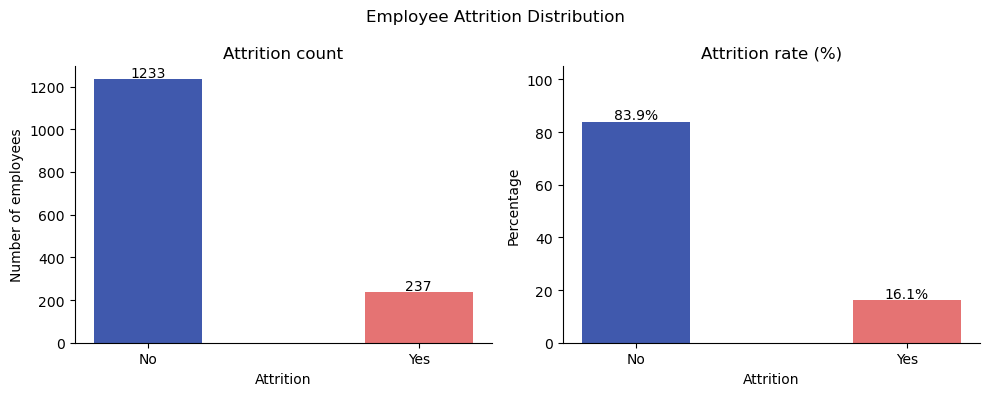

In [266]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#4059AD', '#E57373']

# Left plot counts
attrition_counts = hr_data['Attrition'].value_counts()
bars = axes[0].bar(attrition_counts.index, attrition_counts.values, color=colors, width = 0.4, align = 'center')
axes[0].set_title('Attrition count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Number of employees')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right plot percentages  
attrition_pct = hr_data['Attrition'].value_counts(normalize=True).mul(100)
bars2 = axes[1].bar(attrition_pct.index, attrition_pct.values, color=colors, width = 0.4, align = 'center')
axes[1].set_title('Attrition rate (%)')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Percentage')
axes[1].set_ylim(0, 105)

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
        
plt.suptitle('Employee Attrition Distribution')
plt.tight_layout()
plt.show()

The dataset is imbalanced as 83.9% of employees stayed and 16.1% left. It is a positive business outcome but a challenge for modelling. A classifier that always predicts "No" would achieve 83.9% accuracy without learning anything meaningful. 
This class imbalance will be addressed in Section 4.

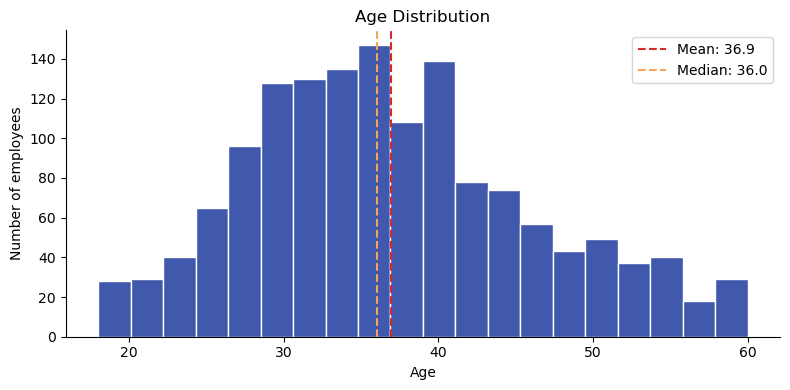

In [267]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(hr_data['Age'], bins=20, color='#4059AD', edgecolor='white')
ax.axvline(hr_data['Age'].mean(), color='#D62828', linestyle='--', label=f"Mean: {hr_data['Age'].mean():.1f}")
ax.axvline(hr_data['Age'].median(), color='#F2A65A', linestyle='--', label=f"Median: {hr_data['Age'].median():.1f}")
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

The age distribution is approximately normal centered around 36-37 years. The workforce is predominantly mid career with relatively few employees under 25 or over 55.

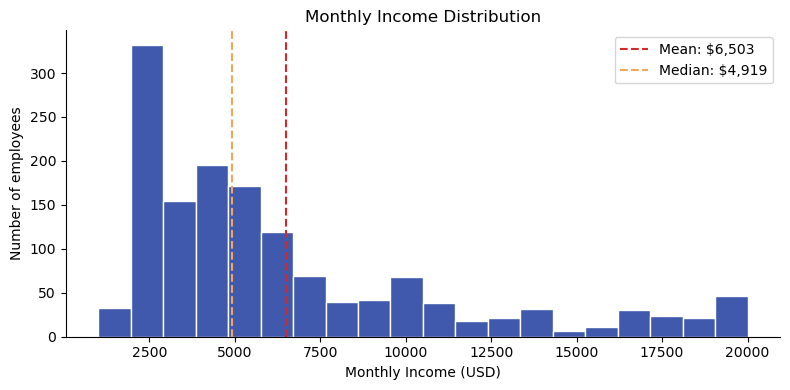

In [268]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(hr_data['MonthlyIncome'], bins=20, color='#4059AD', edgecolor='white')
ax.axvline(hr_data['MonthlyIncome'].mean(), color='#D62828', linestyle='--', label=f"Mean: ${hr_data['MonthlyIncome'].mean():,.0f}")
ax.axvline(hr_data['MonthlyIncome'].median(), color='#F2A65A', linestyle='--', label=f"Median: ${hr_data['MonthlyIncome'].median():,.0f}")

ax.set_title('Monthly Income Distribution')
ax.set_xlabel('Monthly Income (USD)')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

Monthly income is right skewed. The majority of employees earn between 2000 - 5000 USD with a long tail toward higher salaries. The mean ( 6503 USD) is significantly higher than the median (4919 USD) driven by a smaller group of high earners. This skewness is relevant for H2 - the relationship between income and attrition may not be linear.

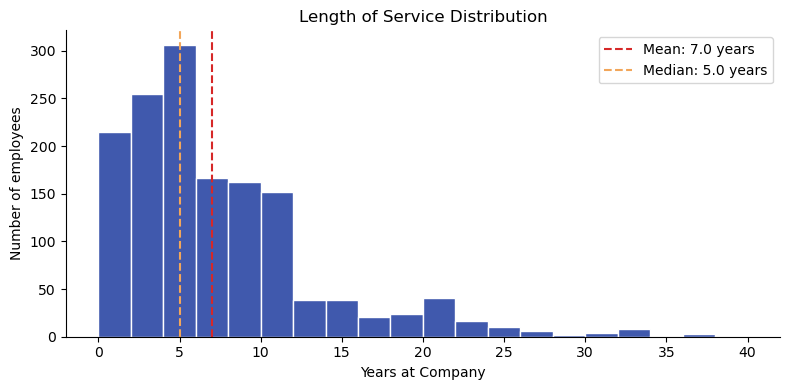

In [269]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(hr_data['YearsAtCompany'], bins=20, color='#4059AD', edgecolor='white')
ax.axvline(hr_data['YearsAtCompany'].mean(), color='#D62828', linestyle='--', label=f"Mean: {hr_data['YearsAtCompany'].mean():.1f} years")
ax.axvline(hr_data['YearsAtCompany'].median(), color='#F2A65A', linestyle='--', label=f"Median: {hr_data['YearsAtCompany'].median():.1f} years")

ax.set_title('Length of Service Distribution')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

plt.tight_layout()
plt.show()

Length of service is strongly right skewed. Most employees have fewer than 10 years at the company where the median is 5 years. The long tail suggests a stable core of long term employees combined with high early-stage turnover. This pattern is consistent with H5 (attrition risk is expected to be highest in the first few years of employment).

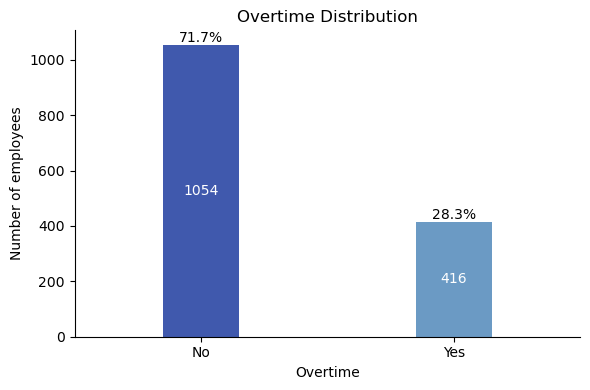

In [270]:
fig, ax = plt.subplots(figsize=(6, 4))

overtime_counts = hr_data['OverTime'].value_counts()
overtime_pct = overtime_counts / overtime_counts.sum() * 100

bars = ax.bar(overtime_counts.index, overtime_counts.values, color=['#4059AD', '#6B9AC4'], width=0.3)
ax.set_title('Overtime Distribution')
ax.set_xlabel('Overtime')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim (-0.5, 1.5)

for bar, pct in zip(bars, overtime_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=10, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

28% of employees (416 out of 1470) work overtime. This is a significant proportion and directly relevant to H1 - whether overtime combined with low job satisfaction is a stronger predictor of attrition than either factor alone.

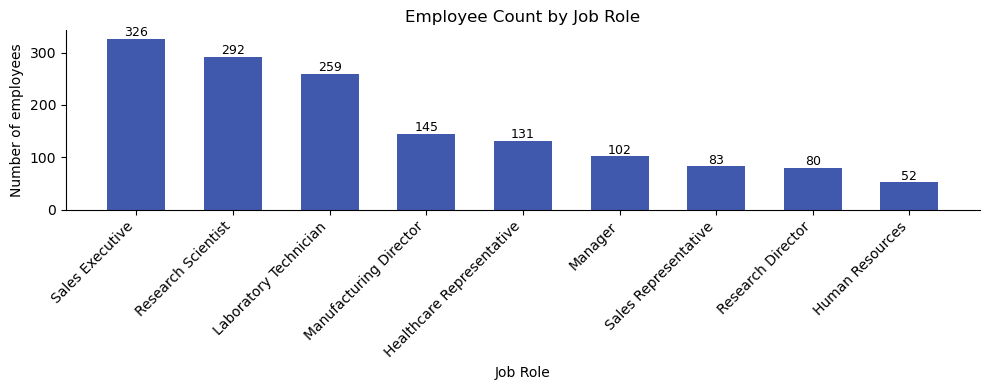

In [271]:
fig, ax = plt.subplots(figsize=(10, 4))

jobrole_counts = hr_data['JobRole'].value_counts()
bars = ax.bar(jobrole_counts.index, jobrole_counts.values, color='#4059AD', width=0.6)

ax.set_title('Employee Count by Job Role')
ax.set_xlabel('Job Role')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(int(bar.get_height())), ha='center', fontsize=9)
    
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sales Executive, Research Scientist and Laboratory Technician are the three largest groups. Human resources is the smallest with only 52 employees. The role distribution is relevant for H5 - we expect tenure and attrition to differ significantly across these groups.

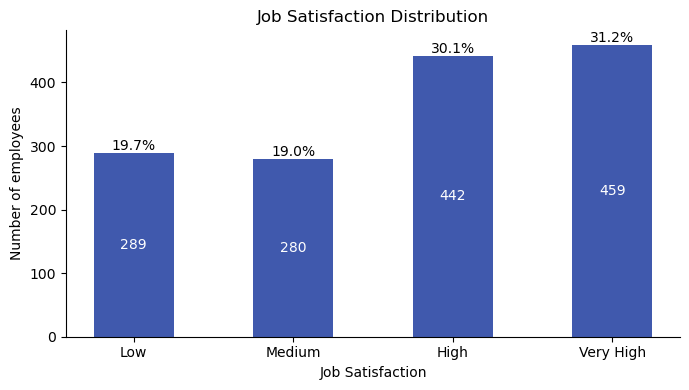

In [272]:
fig, ax = plt.subplots(figsize=(7, 4))

satisfaction_counts = hr_data['JobSatisfaction'].value_counts().sort_index()
satisfaction_pct = satisfaction_counts / satisfaction_counts.sum() * 100
labels = ['Low', 'Medium', 'High', 'Very High']

bars = ax.bar(labels, satisfaction_counts.values, color='#4059AD', width=0.5)
ax.set_title('Job Satisfaction Distribution')
ax.set_xlabel('Job Satisfaction')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, pct in zip(bars, satisfaction_pct.values):
    
    #Absolute value inside the bar
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=10, color='white')
    
    #Percentage above the bar
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Job satisfaction is relatively evenly distributed across the four levels with slightly more employees reporting high (30.3%) and very high (28.8%) satisfaction than low (19.8%) or medium (21.1%). This even distribution provides good base for testing H1 and H3.

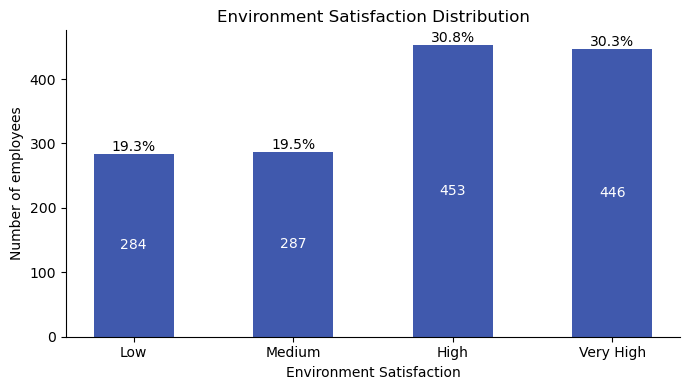

In [273]:
fig, ax = plt.subplots(figsize=(7, 4))

env_counts = hr_data['EnvironmentSatisfaction'].value_counts().sort_index()
env_pct = env_counts / env_counts.sum() * 100
labels = ['Low', 'Medium', 'High', 'Very High']

bars = ax.bar(labels, env_counts.values, color='#4059AD', width=0.5)
ax.set_title('Environment Satisfaction Distribution')
ax.set_xlabel('Environment Satisfaction')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, pct in zip(bars, env_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=10, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Environment satisfaction shows a very similar distribution to job satisfaction with slightly more employees reporting high (32.9%) and very high (27.8%) levels. The near identical distributions suggest these two variables may be correlated which is worth testing in Section 4. If they are strongly correlated it becomes 
more interesting to ask which one is the stronger independent predictor of attrition (H3).

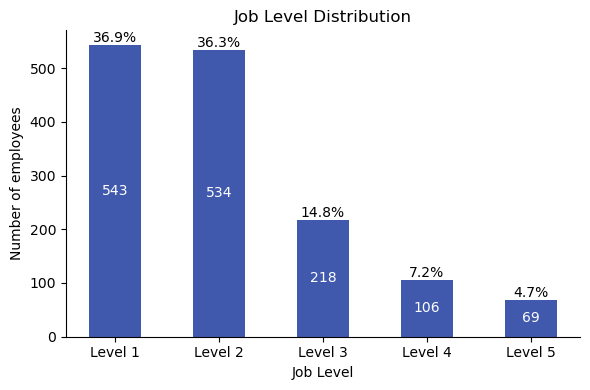

In [274]:
fig, ax = plt.subplots(figsize=(6, 4))

joblevel_counts = hr_data['JobLevel'].value_counts().sort_index()
joblevel_pct = joblevel_counts / joblevel_counts.sum() * 100

bars = ax.bar(['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5'], joblevel_counts.values, color='#4059AD', width=0.5)
ax.set_title('Job Level Distribution')
ax.set_xlabel('Job Level')
ax.set_ylabel('Number of employees')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, pct in zip(bars, joblevel_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=10, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

The workforce is predominantly junior to mid level - Level 1 (36.9%) and Level 2 (36.3%)together account for 73% of all employees. Senior levels (4 and 5) represent only 11.9%. This structure is typical for large organizations and is directly relevant for H2 and H5. We already saw that L1 has a disproportionately high attrition rate of 26.3%

### 3.2 Stack Overflow Developer Survey 2025 dataset (univariate analysis)
Before analysing the relevant columns, a brief inspection of the dataset confirms its structure and data types.

In [275]:
print(so_data.columns.tolist())

['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'JobSatPoints_13', 'JobSatPoints_14', 'JobSatPoints_15', 'JobSatPoints_16', 'JobSatPoints_15_TEXT', 'AIThreat', 'NewRole', 'ToolCountWork', 'ToolCountPersona

In [276]:
so_data.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat,AttritionIntent
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0,0.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0,1.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0,1.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0,0.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0,0.0


In [277]:
so_data.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat,AttritionIntent
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000,35527.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950,0.543868
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245,0.498079
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000,0.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000,1.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000,1.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000,1.000000


In [278]:
so_data.dtypes

ResponseId               int64
MainBranch              object
Age                     object
EdLevel                 object
Employment              object
                        ...   
AIHuman                 object
AIOpen                  object
ConvertedCompYearly    float64
JobSat                 float64
AttritionIntent        float64
Length: 173, dtype: object

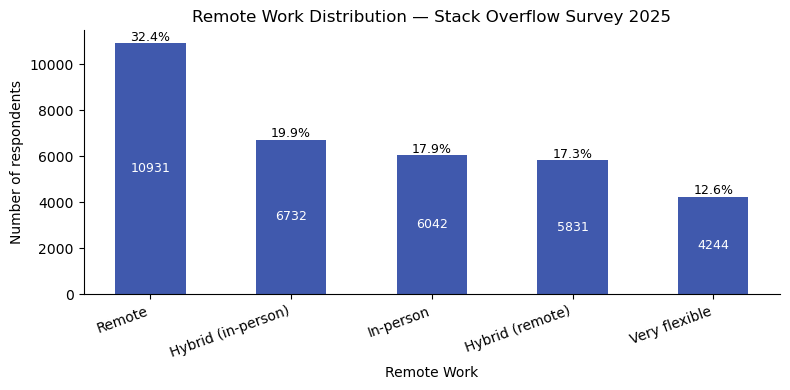

In [279]:
remote_labels = {
    'Remote': 'Remote',
    'Hybrid (some remote, leans heavy to in-person)': 'Hybrid (in-person)',
    'In-person': 'In-person',
    'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid (remote)',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'Very flexible'
}

so_data['RemoteWork_short'] = so_data['RemoteWork'].map(remote_labels)

remote_counts = so_data['RemoteWork_short'].value_counts()
remote_pct = remote_counts / remote_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(remote_counts.index, remote_counts.values, color='#4059AD', width=0.5)
ax.set_title('Remote Work Distribution — Stack Overflow Survey 2025')
ax.set_xlabel('Remote Work')
ax.set_ylabel('Number of respondents')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, pct in zip(bars, remote_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=9, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{pct:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

32.4% of respondents work fully remote and 17.3% have a very flexible or hybrid arrangement leaning toward remote - together 62.3% have significant location autonomy. In contrast, 17.9% work fully in-person and 19.9% are in a hybrid arrangement leaning toward in-person - together 37.8% have limited flexibility. This distribution confirms that remote work flexibility is the current trend in tech (approximately 2/3 of respondents) - relevant context for H4.

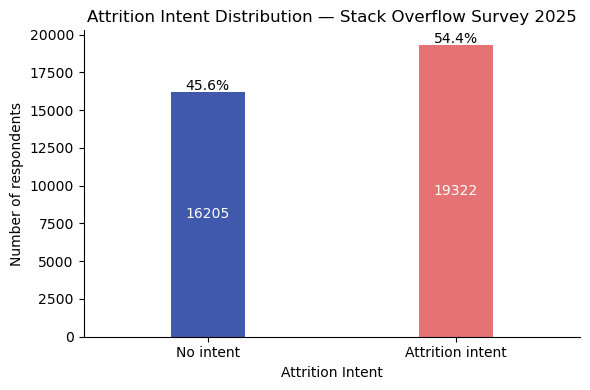

In [280]:
fig, ax = plt.subplots(figsize=(6, 4))

intent_counts = so_data['AttritionIntent'].value_counts().sort_index()
intent_pct = intent_counts / intent_counts.sum() * 100

bars = ax.bar(['No intent', 'Attrition intent'], intent_counts.values, color=['#4059AD', '#E57373'], width=0.3)
ax.set_title('Attrition Intent Distribution — Stack Overflow Survey 2025')
ax.set_xlabel('Attrition Intent')
ax.set_ylabel('Number of respondents')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim (-0.5, 1.5)

for bar, pct in zip(bars, intent_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=10, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

54.4% of respondents show some level of attrition intent and they are either considering or have already transitioned to a new role. This high proportion is possible to be inflated by selection bias as people actively considering a change are more motivated to complete a developer survey. This is documented as a limitation in Section 1.4.

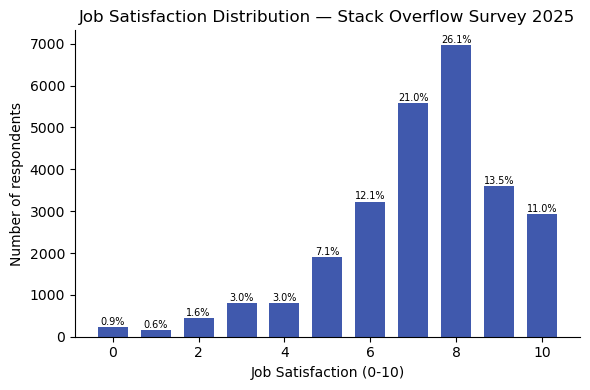

In [281]:
fig, ax = plt.subplots(figsize=(6, 4))

jobsat_counts = so_data['JobSat'].value_counts().sort_index()
jobsat_pct = jobsat_counts / jobsat_counts.sum() * 100

bars = ax.bar(jobsat_counts.index, jobsat_counts.values, color='#4059AD', width=0.7)
ax.set_title('Job Satisfaction Distribution — Stack Overflow Survey 2025')
ax.set_xlabel('Job Satisfaction (0-10)')
ax.set_ylabel('Number of respondents')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, pct in zip(bars, jobsat_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{pct:.1f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.show()

Job satisfaction among tech workers is skewed toward higher values - the most common score is 8 (26.1%) and over 70% of the respondents rate their satisfaction at 7 or above.This suggests that the survey respondents are generally satisfied which may limit the signals for H7. Low satisfaction (0-4) represents only 9.2% of respondeхts.

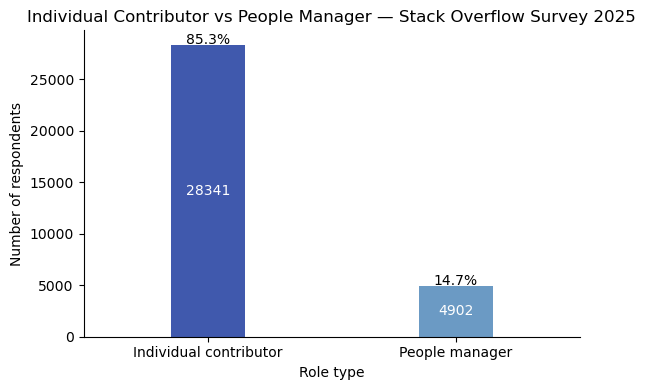

In [282]:
fig, ax = plt.subplots(figsize=(6, 4))

icorpm_counts = so_data['ICorPM'].value_counts()
icorpm_pct = icorpm_counts / icorpm_counts.sum() * 100
bar_colors = ['#4059AD', '#6B9AC4']

bars = ax.bar(icorpm_counts.index, icorpm_counts.values, color=bar_colors, width=0.3)
ax.set_title('Individual Contributor vs People Manager — Stack Overflow Survey 2025')
ax.set_xlabel('Role type')
ax.set_ylabel('Number of respondents')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-0.5, 1.5)

for bar, pct in zip(bars, icorpm_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, str(int(bar.get_height())), ha='center', va='center', fontsize=10, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{pct:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

85.3% of respondents are individual contributors and 14.7% are people managers. This ratio is typical for tech organizations and provides sufficient sample size in both groups for testing H8 whether individual contributors show higher attrition intent than people managers.

### 3.3 Bivariate Analysis

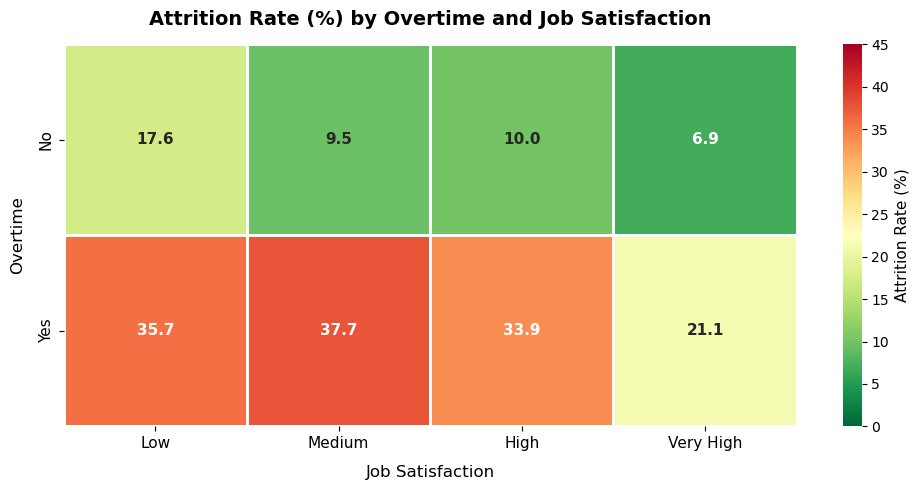

In [283]:
fig, ax = plt.subplots(figsize=(10, 5))

pivot = hr_data.groupby(['OverTime', 'JobSatisfaction'])['Attrition_binary'].mean() * 100
pivot = pivot.unstack()
pivot.columns = ['Low', 'Medium', 'High', 'Very High']

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, linewidths=0.8, linecolor='white', annot_kws={"size": 11, "weight": "bold"}, vmin=0, vmax=45)

ax.set_title('Attrition Rate (%) by Overtime and Job Satisfaction', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Job Satisfaction', fontsize=12, labelpad=10)
ax.set_ylabel('Overtime', fontsize=12, labelpad=10)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)

cbar = ax.collections[0].colorbar
cbar.set_label('Attrition Rate (%)', fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

The heatmap shows clear interaction between overtime and job satisfaction. Employees working overtime with low or medium satisfaction show attrition rates above 35% which is more than double the rates for employees without overtime at the same satisfaction levels. High satisfaction partially mitigates the effect of overtime, reducing attrition to 21.1%. This trend provides visual support for H1.

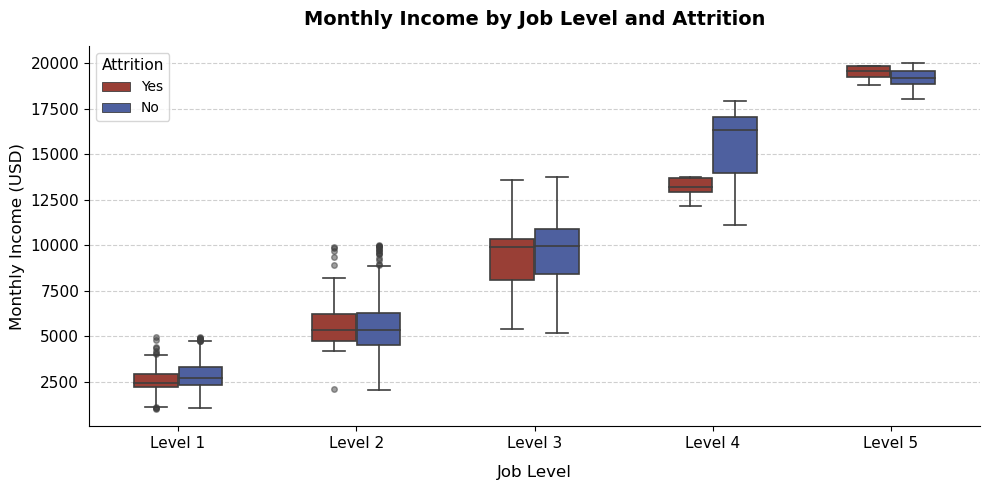

In [284]:
fig, ax = plt.subplots(figsize=(10, 5))

hr_data['JobLevel_label'] = hr_data['JobLevel'].map({1: 'Level 1', 2: 'Level 2', 3: 'Level 3', 4: 'Level 4', 5: 'Level 5'})
order = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

sns.boxplot(data=hr_data, x='JobLevel_label', y='MonthlyIncome', hue='Attrition', order=order, palette={'Yes': '#A93226', 'No': '#4059AD'}, width=0.5, linewidth=1.2, flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}, ax=ax)

ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

ax.set_title('Monthly Income by Job Level and Attrition', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Job Level', fontsize=12, labelpad=10)
ax.set_ylabel('Monthly Income (USD)', fontsize=12)
ax.tick_params(labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title='Attrition', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

The boxplot reveals an interesting pattern for H2. At Level 1 employees who left (Yes) actually show slightly higher median income than those who stayed suggesting that at entry level income alone does not drive attrition. The pattern reverses at Level 4 where employees who left earn noticeably less than those who stayed. At Levels 3 and 5 the distributions overlap significantly. This suggests that the relationship between income and attrition doesn't have the same trend across job levels. Formal testing in Section 4 will determine whether these differences are statistically significant.

Notable outliers appear at Level 1 and 2 in both groups. Some employees left despite higher salaries for their level suggesting non monetary factors drove their departure. Others with similarly high salaries chose 
to stay - consistent with the expectation that higher compensation supports retention. 

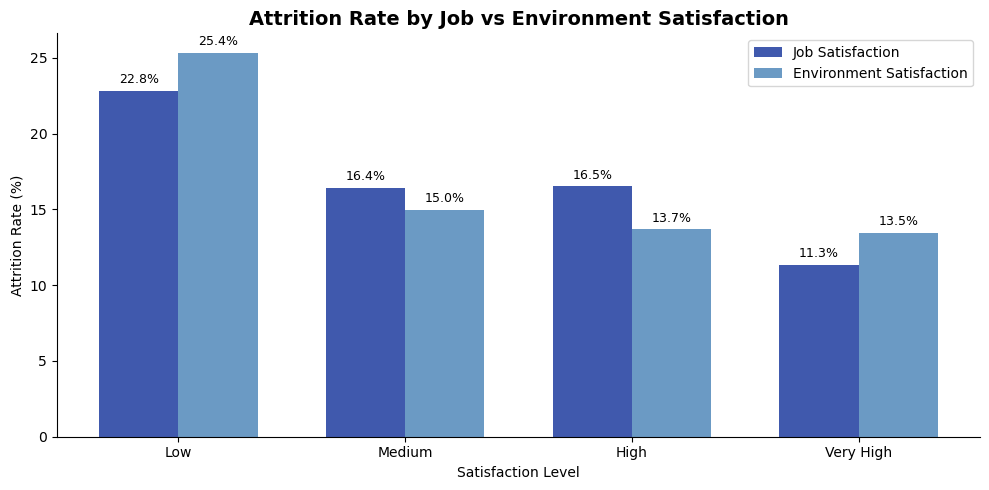

In [285]:
fig, ax = plt.subplots(figsize=(10, 5))

job_sat_rate = hr_data.groupby('JobSatisfaction')['Attrition_binary'].mean() * 100
env_sat_rate = hr_data.groupby('EnvironmentSatisfaction')['Attrition_binary'].mean() * 100
labels = ['Low', 'Medium', 'High', 'Very High']

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, job_sat_rate.values, width, color='#4059AD', label='Job Satisfaction')
bars2 = ax.bar(x + width/2, env_sat_rate.values, width, color='#6B9AC4', label='Environment Satisfaction')

ax.set_title('Attrition Rate by Job vs Environment Satisfaction', fontsize=14, fontweight='bold')
ax.set_xlabel('Satisfaction Level')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Both job satisfaction and environment satisfaction show a consistent negative relationship with attrition: as satisfaction increases attrition rate decreases. The two variables follow nearly identical trends across all four levels with no dramatic differences between them.

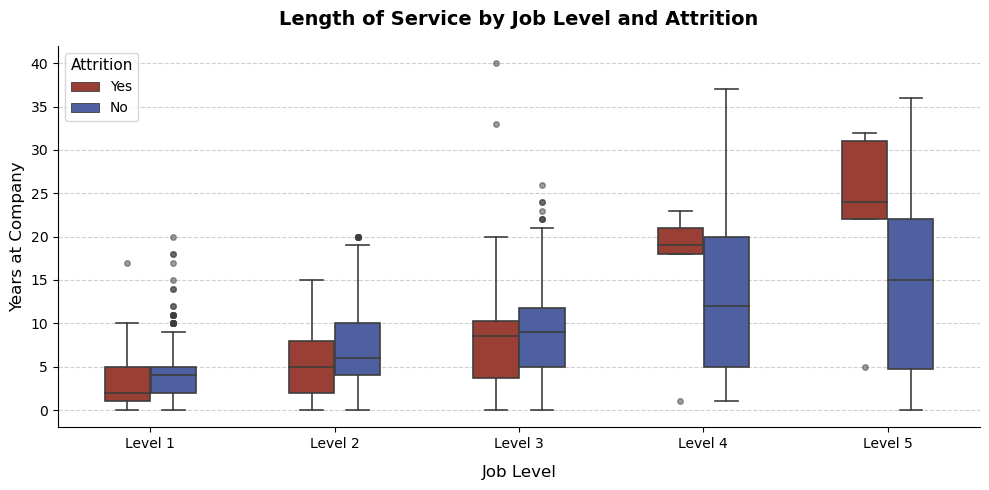

In [286]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=hr_data, x='JobLevel_label', y='YearsAtCompany', hue='Attrition', order=['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5'],
palette={'Yes': '#A93226', 'No': '#4059AD'}, width=0.5, linewidth=1.2, flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},ax=ax)

ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.set_title('Length of Service by Job Level and Attrition',fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Job Level', fontsize=12, labelpad=10)
ax.set_ylabel('Years at Company', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title='Attrition', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()

Length of service differs notably across job levels. At level 1-3 employees who left and those who stayed show similar tenure distributions suggesting that early attrition is not driven by how long someone has been at the company. At level 4 and 5 there is a strong trend that employees who left had longer median tenure than those who stayed. This is consistent with a career ceiling effect - the point at which growth opportunities within the current role or company become limited prompting long term employees to seek opportunities elsewhere. Formal testing in Section 4 will confirm whether these differences are statistically significant.

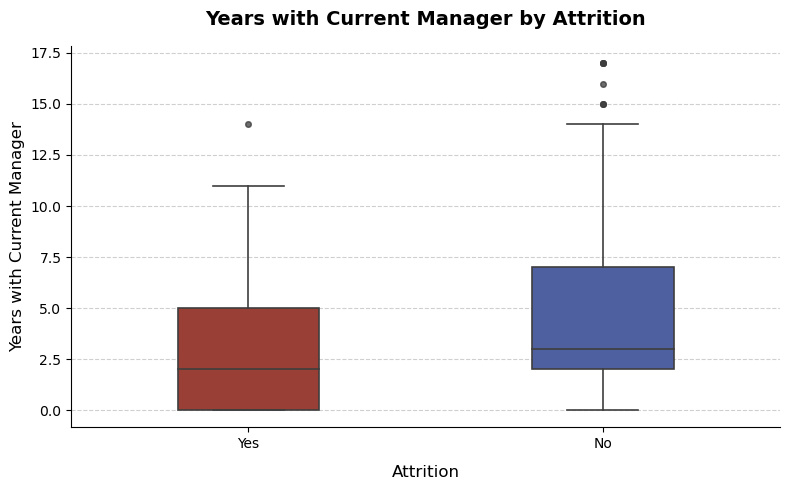

In [287]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=hr_data, x='Attrition', y='YearsWithCurrManager', palette={'Yes': '#A93226', 'No': '#4059AD'}, width=0.4,
linewidth=1.2, flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}, ax=ax)

ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.set_title('Years with Current Manager by Attrition', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Attrition', fontsize=12, labelpad=10)
ax.set_ylabel('Years with Current Manager', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Employees who left show a notably lower median years with current manager (2.5 years) compared to those who stayed (3.5 years) with a much wider range in the "No" group. This suggests that longer relationships with the same manager are associated with lower attrition — consistent with H6. The pattern shows that manager continuity acts as a stabilizing factor independent of other variables. Formal testing in Section 4 will confirm statistical significance.

## Section 4 - Mathematical Methods and Hypothesis Testing

EDA in Section 3 presented visual patterns in the data. This section determines whether those patterns are statistically significant or could simply be the result of chance.

All tests use a significance level of α = 0.05 — meaning a 5% probability of rejecting H₀ when it is actually true is considered acceptable. Failing to reject H₀ does not mean H₀ is true. It means the available evidence is insufficient to reject it.

Three methods are applied:

- **Chi-square test** tests whether two categorical variables are independent of each other
- **Independent t-test** tests whether two groups have the same mean on a numerical variable
- **ANOVA** tests whether the means of more than two groups are equal

For each test the test statistic and p-value are reported and interpreted in the context of the corresponding hypothesis.

### 4.1 H1 Overtime and Job Satisfaction as Combined Predictors of Attrition

**Method: Chi-square test (preliminary) + Logistic Regression (main test)**

The chi-square test is used first as a preliminary check to confirm that overtime and attrition are associated at all before testing the interaction effect. The main test for H1 is logistic regression with an interaction term which will determine whether the effect of overtime on attrition differs across job satisfaction levels. A large χ² statistic indicates that the observed distribution differs substantially from the expected one - evidence against H₀.

$$\chi^2 = \sum \frac{(f_{observed} - f_{expected})^2}{f_{expected}}$$

Where $f_{observed}$ is the actual count in each cell of the table and $f_{expected}$ is what would be expected under the assumption of independence.

**Preliminary check (chi-square):**  
H₀: Overtime and attrition are independent: attrition rate does not differ between employees with and without overtime.  
H₁: Overtime and attrition are significantly associated.

**Main test (logistic regression):**  
H₀: The effect of overtime on attrition does not differ across job satisfaction levels.  
H₁: Overtime has a significantly stronger effect on attrition among employees with low job satisfaction: the two factors interact rather than act independently.

In [288]:
contingency_table = pd.crosstab(hr_data['OverTime'], hr_data['Attrition'])
print("Contingency table:")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}")
print(f"\nConclusion: {'Reject H₀' if p < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Contingency table:
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

Chi-square statistic: 87.5643
Degrees of freedom: 1
p-value: 0.000000

Conclusion: Reject H₀ at α = 0.05


**Result: H₀ rejected (χ² = 87.56, p < 0.001)**

The chi-square statistic of 87.56 is very large and the p-value is zero (far below the α = 0.05 threshold). This means the association between overtime and attrition is statistically significant and very unlikely to be due to chance.

Looking at the table: the attrition rate among employees without overtime is 10.4% and nearly three times higher (30.5%) among employees with overtime.

This confirms H₁ — overtime is strongly associated with higher attrition. However this test treats overtime as a single predictor. The interaction with job satisfaction (the core of H1) will be explored further through logistic regression.

In [289]:
satisfaction_levels = [1, 2, 3, 4]
satisfaction_labels = ['Low', 'Medium', 'High', 'Very High']

for level, label in zip(satisfaction_levels, satisfaction_labels):
    
    employees_at_level = hr_data[hr_data['JobSatisfaction'] == level]
    overtime_vs_attrition = pd.crosstab(employees_at_level['OverTime'], employees_at_level['Attrition'])
    
    chi2_stat, p_value, degrees_of_freedom, _ = chi2_contingency(overtime_vs_attrition)
    
    attrition_rate_no_overtime = employees_at_level[employees_at_level['OverTime'] == 'No']['Attrition_binary'].mean() * 100
    attrition_rate_with_overtime = employees_at_level[employees_at_level['OverTime'] == 'Yes']['Attrition_binary'].mean() * 100
    
    print(f"JobSatisfaction = {label}")
    print(f"  Attrition without overtime: {attrition_rate_no_overtime:.1f}%")
    print(f"  Attrition with overtime:    {attrition_rate_with_overtime:.1f}%")
    print(f"  Chi-square p-value: {p_value:.4f}")
    print()

JobSatisfaction = Low
  Attrition without overtime: 17.6%
  Attrition with overtime:    35.7%
  Chi-square p-value: 0.0015

JobSatisfaction = Medium
  Attrition without overtime: 9.5%
  Attrition with overtime:    37.7%
  Chi-square p-value: 0.0000

JobSatisfaction = High
  Attrition without overtime: 10.0%
  Attrition with overtime:    33.9%
  Chi-square p-value: 0.0000

JobSatisfaction = Very High
  Attrition without overtime: 6.9%
  Attrition with overtime:    21.1%
  Chi-square p-value: 0.0000



In [290]:
results_data = {
    'Job Satisfaction': ['Low', 'Medium', 'High', 'Very High'],
    'With Overtime (%)': [35.7, 37.7, 33.9, 21.1],
    'Without Overtime (%)': [17.6, 9.5, 10.0, 6.9],
    'Difference (percentage points)': [18.1, 28.2, 23.9, 14.2]
}

results_df = pd.DataFrame(results_data)
results_df

,Job Satisfaction,With Overtime (%),Without Overtime (%),Difference (percentage points)
0,Low,35.7,17.6,18.1
1,Medium,37.7,9.5,28.2
2,High,33.9,10.0,23.9
3,Very High,21.1,6.9,14.2


**Result: H₁ supported across all satisfaction levels**

The chi-square test is significant at all four job satisfaction levels (p < 0.05 in all cases) confirming that overtime is associated with higher attrition regardless of satisfaction level. However, the magnitude of the effect differs.

The largest effect appears at Medium satisfaction 28.2 percentage points (pp), not at Low as H1 predicted. At Very High satisfaction overtime still increases attrition but the effect is notably smaller (14.2pp). This  suggests that very high satisfaction partially buffers the negative effect of overtime consistent with the interaction hypothesis though not exactly in the direction predicted.

H₁ is partially supported: overtime significantly increases attrition at all satisfaction levels but the interaction pattern is more nuanced than expected.

### 4.2 H3 Work Environment and Job Satisfaction as Predictors of Attrition

**Method: Independent t-test (preliminary check)**

The t-test compares the mean satisfaction scores between employees who left and those who stayed. It tests whether the difference between two group means is statistically significant.

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

This is a preliminary check only. The full test for H3 requires multiple logistic regression with standardized coefficients to determine which variable is the stronger independent predictor (documented as a planned extension in Section 5).

H₀: JobSatisfaction and EnvironmentSatisfaction contribute equally to predicting attrition.  
H₁: EnvironmentSatisfaction is a stronger independent predictor of attrition than JobSatisfaction.

In [291]:
employees_who_stayed = hr_data[hr_data['Attrition'] == 'No']
employees_who_left = hr_data[hr_data['Attrition'] == 'Yes']

t_statistic_jobsat, p_value_jobsat = ttest_ind(employees_who_stayed['JobSatisfaction'], employees_who_left['JobSatisfaction'])

t_statistic_envsat, p_value_envsat = ttest_ind(employees_who_stayed['EnvironmentSatisfaction'], employees_who_left['EnvironmentSatisfaction'])

print("Job Satisfaction:")
print(f"  Mean (stayed): {employees_who_stayed['JobSatisfaction'].mean():.2f}")
print(f"  Mean (left):   {employees_who_left['JobSatisfaction'].mean():.2f}")
print(f"  p-value: {p_value_jobsat:.4f}")

print("\nEnvironment Satisfaction:")
print(f"  Mean (stayed): {employees_who_stayed['EnvironmentSatisfaction'].mean():.2f}")
print(f"  Mean (left):   {employees_who_left['EnvironmentSatisfaction'].mean():.2f}")
print(f"  p-value: {p_value_envsat:.4f}")

Job Satisfaction:
  Mean (stayed): 2.78
  Mean (left):   2.47
  p-value: 0.0001

Environment Satisfaction:
  Mean (stayed): 2.77
  Mean (left):   2.46
  p-value: 0.0001


**Preliminary result: both variables significant (p < 0.001)**

Both job satisfaction and environment satisfaction differ significantly between employees who left and those who stayed. Mean scores are nearly identical in both cases — 2.47 for those who left versus 2.78 for those who stayed.

The t-test cannot determine which variable is the stronger predictor when both are included simultaneously. The virtually identical results suggest the two variables are likely correlated. Full comparison requires 
multiple logistic regression.

### 4.3 H5 Length of Service Differs by Job Role

**Method: ANOVA (Analysis of variance)**

ANOVA tests whether the means of more than two groups are equal by comparing the variance between groups to the variance within groups.

$$F = \frac{\text{variance between groups}}{\text{variance within groups}}$$

A large F-statistic means the group means differ more than would be expected by chance.

H₀: Tenure does not differ significantly across job roles.  
H₁: Tenure differs significantly across job roles.

In [292]:
job_roles = hr_data['JobRole'].unique()

print("Mean tenure by job role:")
for role in job_roles:
    employees_in_role = hr_data[hr_data['JobRole'] == role]
    mean_years = employees_in_role['YearsAtCompany'].mean()
    print(f"  {role}: {mean_years:.1f} years")

tenure_groups = []
for role in job_roles:
    years_for_this_role = hr_data[hr_data['JobRole'] == role]['YearsAtCompany'].values
    tenure_groups.append(years_for_this_role)

f_statistic, p_value = f_oneway(*tenure_groups)

print(f"\nF-statistic: {f_statistic:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"\nConclusion: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Mean tenure by job role:
  Sales Executive: 7.5 years
  Research Scientist: 5.1 years
  Laboratory Technician: 5.0 years
  Manufacturing Director: 7.6 years
  Healthcare Representative: 8.4 years
  Manager: 14.4 years
  Sales Representative: 2.9 years
  Research Director: 10.9 years
  Human Resources: 5.3 years

F-statistic: 44.6855
p-value: 0.000000

Conclusion: Reject H₀ at α = 0.05


### 4.4 H5b Attrition Risk is Highest at Entry Level

**Method: Chi-square test**

H₀: Attrition rate does not differ significantly across JobLevel groups.  
H₁: Attrition rate differs significantly across JobLevel groups with Level 1 showing much higher attrition.

In [293]:
contingency_table_level = pd.crosstab(hr_data['JobLevel'], hr_data['Attrition'])

chi2_stat, p_value_level, dof_level, _ = chi2_contingency(contingency_table_level)

print("Attrition rate by Job Level:")
for level in [1, 2, 3, 4, 5]:
    rate = hr_data[hr_data['JobLevel'] == level]['Attrition_binary'].mean() * 100
    count = len(hr_data[hr_data['JobLevel'] == level])
    print(f"  Level {level}: {rate:.1f}% (n={count})")

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value_level:.6f}")
print(f"Conclusion: {'Reject H₀' if p_value_level < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Attrition rate by Job Level:
  Level 1: 26.3% (n=543)
  Level 2: 9.7% (n=534)
  Level 3: 14.7% (n=218)
  Level 4: 4.7% (n=106)
  Level 5: 7.2% (n=69)

Chi-square statistic: 72.5290
p-value: 0.000000
Conclusion: Reject H₀ at α = 0.05


**H5 Result: H₀ rejected (F = 44.69, p < 0.001)**

Tenure differs significantly across job roles. The range is wide: Sales Representatives average only 2.9 years while Managers average 14.4 years. This confirms H₁ and is consistent with the sources showing that 
customer facing and entry level roles have shorter median tenure than managerial ones.

**H5b Result: H₀ rejected (χ² = 72.53, p < 0.001)**

Attrition rate differs significantly across job levels. Level 1 shows disproportionately high attrition at 26.3% (more than double any other level). The pattern is non linear: Level 3 shows a secondary peak at 14.7% before dropping again at senior levels. This confirms H₁ and is consistent with the document on retention motivators: junior employees face the highest attrition risk due to unmet growth expectations and financial pressures.

### 4.5 H6 Manager Continuity as a Stabilizing Factor

**Method: Independent t-test (preliminary check)**

H₀: The length of time working with the same manager is not related with attrition risk.  
H₁: Employees who have worked with the same manager for longer show lower attrition risk independently of job satisfaction.

In [294]:
employees_who_stayed = hr_data[hr_data['Attrition'] == 'No']
employees_who_left = hr_data[hr_data['Attrition'] == 'Yes']

manager_years_stayed = employees_who_stayed['YearsWithCurrManager']
manager_years_left = employees_who_left['YearsWithCurrManager']

t_statistic, p_value = ttest_ind(manager_years_stayed, manager_years_left)

print(f"Mean years with manager (stayed): {manager_years_stayed.mean():.2f}")
print(f"Mean years with manager (left):   {manager_years_left.mean():.2f}")
print(f"\nt-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"\nConclusion: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'} at α = 0.05")

Mean years with manager (stayed): 4.37
Mean years with manager (left):   2.85

t-statistic: 6.0591
p-value: 0.0000

Conclusion: Reject H₀ at α = 0.05


**Result: H₀ rejected (t = 6.06, p < 0.001)**

Employees who stayed averaged 4.37 years with their current manager compared to 2.85 years for those who left. The result is confirming H₁: longer manager relationships are associated with lower attrition risk.

This is consistent with the broader literature that manager continuity acts as a stabilizing factor through accumulated trust, familiarity and mutual understanding. Whether this effect holds independently of job 
satisfaction requires logistic regression (noted as a planned extension).

### 4.6 H4 Remote Work and Attrition Intent

**Method: Chi-square test (SO dataset)**

H₀: There is no significant difference in attrition intent between employees with access to remote or hybrid work and those required to work fully on-site.  
H₁: Lack of remote work flexibility is associated with higher attrition intent.

Respondents are grouped into two categories based on EDA findings 
(Section 3.2):
- **High flexibility**: Remote + Hybrid (flexible) + Very flexible — 62.3% of sample
- **Limited flexibility**: In-person + Hybrid (in-person) — 37.8% of sample

**Note on sample sizes:** The attrition intent rates in this test are calculated on respondents who answered both the RemoteWork and NewRole questions (n = 28,259). The percentages in the EDA (Section 3.2) are based on all respondents who answered the RemoteWork question (n = 33,780), regardless of whether they answered NewRole. This explains the slight difference in group sizes between the two sections.

In [295]:
remote_flexibility_map = {
    'Remote': 'High flexibility',
    'Hybrid (some in-person, leans heavy to flexibility)': 'High flexibility',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'High flexibility',
    'Hybrid (some remote, leans heavy to in-person)': 'Limited flexibility',
    'In-person': 'Limited flexibility'
}

so_data['RemoteFlexibility'] = so_data['RemoteWork'].map(remote_flexibility_map)
so_h4 = so_data[['RemoteFlexibility', 'AttritionIntent']].dropna()

high_flexibility_group = so_h4[so_h4['RemoteFlexibility'] == 'High flexibility']
limited_flexibility_group = so_h4[so_h4['RemoteFlexibility'] == 'Limited flexibility']

print(f"High flexibility (Remote + Hybrid flexible + Very flexible):")
print(f"  n = {len(high_flexibility_group)}")
print(f"  Attrition intent rate: {high_flexibility_group['AttritionIntent'].mean()*100:.1f}%")

print(f"\nLimited flexibility (In-person + Hybrid in-person):")
print(f"  n = {len(limited_flexibility_group)}")
print(f"  Attrition intent rate: {limited_flexibility_group['AttritionIntent'].mean()*100:.1f}%")

contingency_remote = pd.crosstab(so_h4['RemoteFlexibility'], so_h4['AttritionIntent'])
contingency_remote.columns = ['No intent', 'Attrition intent']

chi2_stat, p_value, dof, _ = chi2_contingency(contingency_remote)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"\nConclusion: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'} at α = 0.05")

High flexibility (Remote + Hybrid flexible + Very flexible):
  n = 17750
  Attrition intent rate: 53.5%

Limited flexibility (In-person + Hybrid in-person):
  n = 10509
  Attrition intent rate: 57.5%

Chi-square statistic: 41.5234
p-value: 0.0000

Conclusion: Reject H₀ at α = 0.05


**Result: H₀ rejected (χ² = 41.52, p < 0.001) - correct direction, small effect**

Employees with limited flexibility (in-person and hybrid leaning in-person) show higher attrition intent (57.5%) than those with high flexibility (remote, hybrid flexible, very flexible) at 53.5% (consistent with H₁).
The 4 percentage point difference is statistically significant but practically small. Two factors explain this:

1. Remote work is already the norm: 62.3% of respondents have significant flexibility. When flexibility is widely available its absence has a smaller marginal effect on attrition intent.
2. Overall attrition intent is inflated across both groups due to selection bias. People actively considering a change are more likely to complete a developer survey.

H₁ is partially supported: the direction is correct but the practical significance is limited given the sample characteristics.

## Section 5 - Conclusions

### 5.1 What the data shows

Attrition is not driven by a single factor. The analysis points to a combination of workload, satisfaction, seniority and manager relationships. The relative importance of each depends on where someone is in 
their career.

**Overtime is the strongest predictor.** Employees working overtime are nearly three times more likely to leave than those who are not (30.5% vs 10.4%). The effect is largest among mid-level employees with medium 
satisfaction consistent with research showing that this group is most sensitive to burnout and work-life balance.

**Entry-level employees leave at the highest rate (26.3%).** This is more than double any other job level and aligns with the finding that junior employees prioritize financial security and career growth above loyalty. When those needs are not met early they leave quickly.

**Manager continuity matters.** Employees who left had worked with their manager for an average of 2.85 years compared to 4.37 years for those who stayed. This 1.5-year difference is statistically significant and  suggests that stable manager relationships act as a retention factor across all seniority levels.

**Satisfaction predicts attrition but job and environment satisfaction are equally strong.** Both variables show the same pattern and the same p-value suggesting they measure overlapping constructs. A more granular 
test would require logistic regression with both variables simultaneously.

**Remote work flexibility has a measurable but small effect.** In the Stack Overflow Survey 2025 employees without flexibility show 4 percentage points higher attrition intent (57.5% vs 53.5%). The effect is real but 
modest probably because remote work is already the norm for 62% of tech workers.


### 5.2 What was not tested

The following were planned but not completed due to time constraints:

- H2 whether the income vs attrition relationship differs by job level (requires logistic regression)
- H7 compensation and satisfaction patterns in the SO dataset
- H8 attrition intent differences between individual contributors and people managers
- Full logistic regression for H1 and H3 with interaction terms

### 5.3 Limitations

- The HR Attrition dataset is synthetic: findings cannot be generalized to real organizations
- All associations are correlational: causality cannot be established
- The SO Survey sample over represents people actively considering a job change, inflating attrition intent figures